## Metrics Evaluation Lab

Throughout your early career as a Data Scientist you've spent most your time cleaning data, but now you are starting to build models and have come to realize the most important part about understanding any machine learning model (or any model, really) is understanding its weakness and vulnerabilities.

In doing so you've decided to practice on a dataset about mushrooms, because after all if you don't know how to evaluate a model thoroughly you'll be in real **truffle** (ha...ha) and introduce a approach that is new to you. 

Below I've build an initial **Decision Tree** model on the mushroom dataset to get you started. Think of the Decision Tree as your field guide – splitting mushrooms into categories one feature at a time. 

### Part 1: Load and Clean

Using the [mushroom dataset](https://archive.ics.uci.edu/static/public/848/secondary+mushroom+dataset.zip) and the documentation below answer the provided question. 

- [Mushroom Documentation](https://archive.ics.uci.edu/dataset/848/secondary+mushroom+dataset)

*How well can we predict whether a mushroom is poisonous or edible based on its physical characteristics?* 

### Part 2: Build the model

This will most be provided for you, but some details you'll need to code yourself. 

### Part 3: Evaluate and assess

Consider where classification errors are occurring, is there a pattern? If so discuss this pattern and why you think this is the case. Use the confusion matrix to determine the pattern. 

### Keys to Success

- Using the evaluation metrics correctly: we are focusing on classification not regression
- Evaluation is not about the metrics per se, but what they mean; speaking through your question in light of the evaluation metrics is the primary objective of this lab. Think of yourself as a "model detective" that works to leave no stone unturned!
- Remember, be patient and double check your code or you might find yourself in real **shiitake** :)

---
## Initial Decision Tree Model – Starter Code

The code below walks you through an initial Decision Tree classifier on the mushroom dataset. Use it as a *spore*-ing board (sorry, not sorry) to complete the lab.

### Step 1 – Imports

In [1]:
# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn import metrics

### Step 2 – Load the Mushroom Dataset

We load the mushroom dataset directly. The target column is `type` (poisonous **p** vs edible **e**). 

For the full lab you may want to use the secondary mushroom dataset from UCI:
- [Download](https://archive.ics.uci.edu/static/public/848/secondary+mushroom+dataset.zip)
- [Documentation](https://archive.ics.uci.edu/dataset/848/secondary+mushroom+dataset)

In [2]:
# Load the mushroom dataset
mushroom_url = (
    "https://raw.githubusercontent.com/stedy/"
    "Machine-Learning-with-R-datasets/master/mushrooms.csv"
)

mushroom_data = pd.read_csv(mushroom_url)

print(f'Dataset shape: {mushroom_data.shape}')
mushroom_data.head()

Dataset shape: (8124, 23)


,type,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### Step 3 – Explore the Data

In [3]:
# Use the various exploration methods we covered in class to understand the dataset.
mushroom_data.describe()

,type,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [4]:
mushroom_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   type                      8124 non-null   str  
 1   cap_shape                 8124 non-null   str  
 2   cap_surface               8124 non-null   str  
 3   cap_color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill_attachment           8124 non-null   str  
 7   gill_spacing              8124 non-null   str  
 8   gill_size                 8124 non-null   str  
 9   gill_color                8124 non-null   str  
 10  stalk_shape               8124 non-null   str  
 11  stalk_root                8124 non-null   str  
 12  stalk_surface_above_ring  8124 non-null   str  
 13  stalk_surface_below_ring  8124 non-null   str  
 14  stalk_color_above_ring    8124 non-null   str  
 15

In [5]:
# Check for missing values
mushroom_data.isna().sum()
# no missing values! 

type                        0
cap_shape                   0
cap_surface                 0
cap_color                   0
bruises                     0
odor                        0
gill_attachment             0
gill_spacing                0
gill_size                   0
gill_color                  0
stalk_shape                 0
stalk_root                  0
stalk_surface_above_ring    0
stalk_surface_below_ring    0
stalk_color_above_ring      0
stalk_color_below_ring      0
veil_type                   0
veil_color                  0
ring_number                 0
ring_type                   0
spore_print_color           0
population                  0
habitat                     0
dtype: int64

### Step 4 – Clean & Prepare the Data



In [6]:
# Separate features (X) and target (y)
# Our target is 'type' – predicting poisonous (p) vs edible (e)
y = mushroom_data['type']
X = mushroom_data.drop('type', axis=1).copy()

In [7]:
# Calculate prevalence – how common is each class?
# This tells us what accuracy we'd get if we just guessed the majority class every time.
# If our model can't beat the prevalence, it's about as useful as a chocolate teapot...
# or a poisonous mushroom at a dinner party 

prevalance = 100*len(y[y=='p'])/len(y)
print(f'The prevalance is {prevalance:.2f}%')

The prevalance is 48.20%


### Collapse factor levels


Check for the levels of the categorical features
This helps us understand the diversity of our features and how they might influence the model 
and if we need to collapse rare categories to avoid overfitting on tiny groups of mushrooms, don't use 
a for loop, `nunique()` will give us the unique values for each column at once, its a function of the dataframe, 
not a function of the column, so we can call it on the whole dataframe and it will return the 
unique values for each column in one go


Then use data wrangler or another method to identify features that need to be collapsed, 
for example if a feature has 10 levels but 9 of them are very rare, 
we might want to collapse those 9 levels into an "other" 
category to avoid overfitting on those rare categories, this is especially 
important for decision trees which can easily overfit on rare categories

In [8]:
# Collapse rare categories in the 'habitat' feature
# This is a common preprocessing step to avoid overfitting on rare categories,
# especially important for decision trees which can easily overfit on rare categories
# X['habitat'] = X['habitat'].replace(['u', 'd'], 'other') # in this example we are simply replacing the 'u' and 'd' 

# categories with 'other', but in a real analysis we would want to look at the distribution of the categories and 
# decide which ones to collapse based on their frequency and importance to the model, 
# this is just an example to show how to do it, 
# you would need to adjust it based on your specific dataset and analysis needs

# Other functions that might be helpful for this step include value_counts(), where() and isin() 
# sample code for how that might look, but again you would need to adjust it based on your specific dataset and analysis needs

# top_cats = df['col'].value_counts().nlargest(2).index # this would give us the top 2 most common categories in the 'col' feature,
# df['new_col'] = df['col'].where(df['col'].isin(top_cats), 'Other') # this would create a new column 'new_col' where the 
# values are the same as 'col' for the top 2 categories,and 'Other' for all other categories,
# this is a common way to collapse rare categories into an 'Other' category,
# but again you would need to adjust it based on your specific dataset and analysis needs.

In [9]:
# use nunique() to see what features in the data frame we need to collapse
mushroom_data.nunique()

type                         2
cap_shape                    6
cap_surface                  4
cap_color                   10
bruises                      2
odor                         9
gill_attachment              2
gill_spacing                 2
gill_size                    2
gill_color                  12
stalk_shape                  2
stalk_root                   5
stalk_surface_above_ring     4
stalk_surface_below_ring     4
stalk_color_above_ring       9
stalk_color_below_ring       9
veil_type                    1
veil_color                   4
ring_number                  3
ring_type                    5
spore_print_color            9
population                   6
habitat                      7
dtype: int64

In [10]:
# from looking at the number of unique values and the distribution of each value in data wrangler, 
# cap_shape, cap_color, odor, gill_color, stalk_root, stalk_surface_above_ring, stalk_surface_below_ring, 
# stalk_color_above_ring, stalk_color_below_ring, ring_type, spore_print_color, population, veil_color
# and habitat can all be collapsed

# use the method shown above to retrieve the top n (adjusted based on percentages seen in data wrangler) values in
# a column and keep those values, changing all other values to other 

top_cats = mushroom_data['cap_shape'].value_counts().nlargest(2).index 
mushroom_data['cap_shape_c'] = mushroom_data['cap_shape'].where(mushroom_data['cap_shape'].isin(top_cats), 'Other')
top_cats = mushroom_data['cap_color'].value_counts().nlargest(3).index 
mushroom_data['cap_color_c'] = mushroom_data['cap_color'].where(mushroom_data['cap_color'].isin(top_cats), 'Other')
top_cats = mushroom_data['odor'].value_counts().nlargest(2).index 
mushroom_data['odor_c'] = mushroom_data['odor'].where(mushroom_data['odor'].isin(top_cats), 'Other')
top_cats = mushroom_data['gill_color'].value_counts().nlargest(3).index 
mushroom_data['gill_color_c'] = mushroom_data['gill_color'].where(mushroom_data['gill_color'].isin(top_cats), 'Other')
top_cats = mushroom_data['stalk_root'].value_counts().nlargest(2).index 
mushroom_data['stalk_root_c'] = mushroom_data['stalk_root'].where(mushroom_data['stalk_root'].isin(top_cats), 'Other')
top_cats = mushroom_data['stalk_surface_above_ring'].value_counts().nlargest(2).index 
mushroom_data['stalk_surface_above_ring_c'] = mushroom_data['stalk_surface_above_ring'].where(mushroom_data['stalk_surface_above_ring'].isin(top_cats), 'Other')
top_cats = mushroom_data['stalk_surface_below_ring'].value_counts().nlargest(2).index 
mushroom_data['stalk_surface_below_ring_c'] = mushroom_data['stalk_surface_below_ring'].where(mushroom_data['stalk_surface_below_ring'].isin(top_cats), 'Other')
top_cats = mushroom_data['stalk_color_above_ring'].value_counts().nlargest(2).index 
mushroom_data['stalk_color_above_ring_c'] = mushroom_data['stalk_color_above_ring'].where(mushroom_data['stalk_color_above_ring'].isin(top_cats), 'Other')
top_cats = mushroom_data['stalk_color_below_ring'].value_counts().nlargest(2).index 
mushroom_data['stalk_color_below_ring_c'] = mushroom_data['stalk_color_below_ring'].where(mushroom_data['stalk_color_below_ring'].isin(top_cats), 'Other')
top_cats = mushroom_data['ring_type'].value_counts().nlargest(2).index 
mushroom_data['ring_type_c'] = mushroom_data['ring_type'].where(mushroom_data['ring_type'].isin(top_cats), 'Other')
top_cats = mushroom_data['spore_print_color'].value_counts().nlargest(3).index 
mushroom_data['spore_print_color_c'] = mushroom_data['spore_print_color'].where(mushroom_data['spore_print_color'].isin(top_cats), 'Other')
top_cats = mushroom_data['population'].value_counts().nlargest(2).index 
mushroom_data['population_c'] = mushroom_data['population'].where(mushroom_data['population'].isin(top_cats), 'Other')
top_cats = mushroom_data['habitat'].value_counts().nlargest(2).index 
mushroom_data['habitat'] = mushroom_data['habitat'].where(mushroom_data['habitat'].isin(top_cats), 'Other')
top_cats = mushroom_data['veil_color'].value_counts().nlargest(1).index 
mushroom_data['veil_color_c'] = mushroom_data['veil_color'].where(mushroom_data['veil_color'].isin(top_cats), 'Other')

In [12]:
mushroom_data.head()

,type,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,gill_color_c,stalk_root_c,stalk_surface_above_ring_c,stalk_surface_below_ring_c,stalk_color_above_ring_c,stalk_color_below_ring_c,ring_type_c,spore_print_color_c,population_c,veil_color_c
0,p,x,s,n,t,p,f,c,n,k,...,Other,Other,s,s,w,w,p,k,Other,w
1,e,x,s,y,t,a,f,c,b,k,...,Other,Other,s,s,w,w,p,n,Other,w
2,e,b,s,w,t,l,f,c,b,n,...,Other,Other,s,s,w,w,p,n,Other,w
3,p,x,y,w,t,p,f,c,n,n,...,Other,Other,s,s,w,w,p,k,Other,w
4,e,x,s,g,f,n,f,w,b,k,...,Other,Other,s,s,w,w,e,n,Other,w


In [13]:
mushroom_data_c = mushroom_data.drop(['cap_shape', 'cap_color', 'odor', 'gill_color', 'stalk_root', 'stalk_surface_above_ring', 
                                      'stalk_surface_below_ring', 'stalk_color_above_ring', 'stalk_color_below_ring', 'ring_type',
                                        'spore_print_color', 'population', 'veil_color', 'habitat'], axis=1)


### Step 5 – Partition the Data

We split our fungi into training, tuning, and test sets.

In [21]:
X_c = mushroom_data_c.drop(['type'], axis=1)
y_c = mushroom_data_c['type']

In [54]:
# 70 / 15 / 15 split – train / tune / test
# Stratify keeps the same ratio of edible:poisonous in each set, which is important for evaluation.
X_train, X_temp, y_train, y_temp = train_test_split(X_c, y_c, train_size=0.7, random_state=42, stratify=y_c)
X_tune, X_test, y_tune, y_test = train_test_split(X_temp, y_temp, train_size=0.5, random_state=42, stratify=y_temp)

In [55]:
categorical_features = X_c.select_dtypes(include='object').columns.tolist() # creating a list of the categorical features, 
# this will be used later for preprocessing in the pipeline, in this example we are using a ordinal encoder 
# which can handle categorical features without needing to one-hot encode them,
# but we need to tell the pipeline which features are categorical so it knows to apply the ordinal encoder to 
# those features and not to the numeric features (if we had any).


# Create a LabelEncoder for the target variable
le_target = LabelEncoder()
le_target.fit(y_c)

# Build decision tree pipeline with OrdinalEncoder preprocessing
dt_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer( #note the preprocessor and the classifier on the same level of the pipeline, 
        #this is important because we want to make sure that the preprocessing is applied to the 
        # training data during cross-validation and grid search, if we put the preprocessor inside the classifier 
        # it would only be applied to the test data and not the training data, which would lead to data leakage and overfitting
        transformers=[
            ('ordinal', OrdinalEncoder(), categorical_features) # applying the ordinal encoder to the categorical features, 
            #this will convert the categorical features into numeric 
            # values that can be used by the decision tree classifier
        ],
        remainder='passthrough'
    )),
    ('classifier', DecisionTreeClassifier(random_state=42, criterion='gini'))
])

# Evaluate with 5-fold cross-validation on training data
cv_scores = cross_val_score(
    dt_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)


# Fit final model on full training data
dt_pipeline.fit(X_train, y_train)


/tmp/ipykernel_4359/1060174674.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_c.select_dtypes(include='object').columns.tolist() # creating a list of the categorical features,


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ordinal', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

---
## Evaluation Metrics

Time to find out how well our tree knows its fungi.

In [56]:
# Generate predictions and predicted probabilities on the tuning set and pass into variables
# Think of probabilities as how confident our tree is, example below
dt_pred = dt_pipeline.predict(X_tune)
dt_prob = dt_pipeline.predict_proba(X_tune)

# Bundle everything into a tidy DataFrame
results = pd.DataFrame({
    'target': y_tune,
    'pred': dt_pred,
    'prob_edible': dt_prob[:, 0], # first column
    'prob_poisonous': dt_prob[:, 1] # second column
})


In [57]:
results.head()

,target,pred,prob_edible,prob_poisonous
3331,p,p,0.0,1.0
4038,p,p,0.0,1.0
3619,e,e,1.0,0.0
6062,p,p,0.0,1.0
5880,p,p,0.0,1.0


#### Confusion Matrix

The confusion matrix shows us where our model is getting confused, build a confusion matrix and see how the model is performing. Give a 2 sentence summary on what you see. 

#### True Positive Rate (Sensitivity / Recall) & False Positive Rate

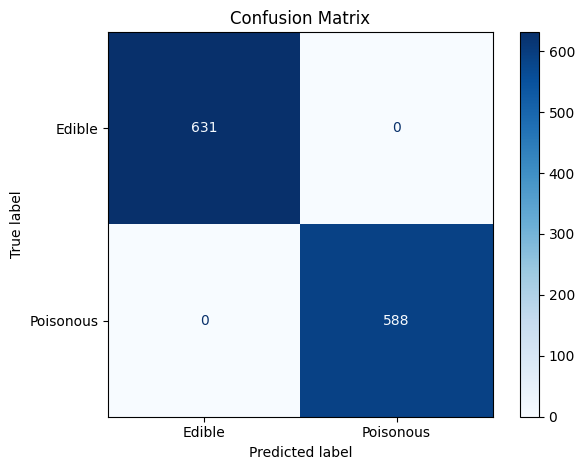

In [58]:
# TPR (True Positive Rate) = Recall = Sensitivity
# Of all the actually poisonous mushrooms, how many did we correctly flag?
# FPR (False Positive Rate) = how many safe mushrooms did we wrongly accuse?

# make the confusion matrix
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    classification_report)
# use the confusion_matrix function to make the confusion matrix of the predictions for the 
# test set versus the actual values (output is a numpy array)
cm_m1 = confusion_matrix(y_tune, dt_pred)
# make a variable that holds the display of the confusion matrix made above 
disp_m1 = ConfusionMatrixDisplay(confusion_matrix=cm_m1, display_labels=['Edible', 'Poisonous'])
# plot the display of the confusion matrix
disp_m1.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


#### Classification Report

In [60]:
# Full classification report – the tasting menu of evaluation metrics 

# print the classification report of the actual and predicted values on the test set 
print(classification_report(y_tune, dt_pred, target_names=['Edible', 'Poisonous']))

              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       631
   Poisonous       1.00      1.00      1.00       588

    accuracy                           1.00      1219
   macro avg       1.00      1.00      1.00      1219
weighted avg       1.00      1.00      1.00      1219



#### ROC Curve & AUC

The ROC curve plots TPR vs FPR at every threshold. AUC (Area Under the Curve) summarises it in one number – 1.0 is perfect, 0.5 is a coin flip.  

### Write a summary of what you found based on the evaluation measures. Include where have you noticed some issues with the model and What metrics do you think we should pay most attention to given the target variable.

 - Do you think we should adjust the threshold from the default value or not? Why or why not?
 -  

---

You now have a working Decision Tree baseline.

**Attempt the Bonus** 5 points each:

Pick a metric we haven’t covered (e.g., Matthews Correlation Coefficient, Precision-Recall AUC, Cohen’s Kappa) and discuss it.

Choose a model we have not present in class and see if the evaluation is better or worse - be specific about the metric you are using for comparison and why the model seems to fit better or worse. 

